# Plot PPI counts. COmpare HCC827 cells from widefield, localized widefield, and SRRF confocal

In [1]:
import numpy as np
import pandas as pd
import time
import os
import sys
from tqdm import tqdm, trange
from datetime import date
import nd2reader
from joblib import Parallel, delayed
import tifffile as tf
import xml.etree.ElementTree as ET
import napari
import skimage
from skimage.io import imread
from skimage.measure import block_reduce
from skimage.filters import try_all_threshold
import dask.array as da
import dask.dataframe as dd
from dask.diagnostics import ProgressBar
import dask
import matplotlib
import matplotlib.pyplot as plt
import nd2
from skimage import exposure, restoration
from joblib import Parallel, delayed
import torch
from cellpose import models, core, plot
import cv2
import scipy
from skimage.morphology import closing, square
from skimage.measure import label
import seaborn as sns
import math
from pathlib import Path
import sklearn
from sklearn.neighbors import KDTree
import networkx
from networkx.algorithms.components.connected import connected_components
import h5py
from datetime import datetime

sns.set(font_scale=2)

%gui qt5

c:\Users\nzhang326\AppData\Local\anaconda3\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Users\nzhang326\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:219: CryptographyDeprecationWarning: Blowfish has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.Blowfish and will be removed from this module in 45.0.0.
  "class": algorithms.Blowfish,
c:\Users\nzhang326\AppData\Local\anaconda3\Lib\site-packages\paramiko\transport.py:243: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from this module in 48.0.0.
  "class": algorithms.TripleDES,


# user directories and inputs

In [2]:
dfPaths = pd.read_excel(Path(r"../data/HCC827 P6 plate 003/01 HCC827 plate 003 microscopes.xlsx"))

# well info
dfInfo = pd.read_excel(Path(r"../data/HCC827 P6 plate 003/15Jul2024 cycle 1 Nicky widefield/23Jul2024_wells_info.xlsx"))

screenshotSavePath = Path(r"../figures")
assert screenshotSavePath.exists()

# Delay execution (optional)

In [3]:
# time.sleep(2 * 60 * 60) # sec

# compute single cell PPI counts

In [4]:
def reformatSingleCell(path, modality, dfInfo):

    df = pd.read_pickle(path)

    # sum dots per cell
    cols = [c for c in df.columns if 'Combo5' in c and 'Intensity' not in c]
    assert len(cols) == 1
    # rename for consistency
    df.rename(columns = {cols[0]: 'Combo5 Dots'}, inplace = True)
    dfCell = df.groupby(['CellLabel']).agg({'Combo5 Dots': 'sum'})
    dfCell.reset_index(drop = False, inplace = True)

    # assign microscope
    dfCell['Microscope'] = modality

    # assign well label
    wellLabel = path.stem
    row = dfInfo.loc[dfInfo['WellLabel'] == wellLabel]
    assert len(row) == 1
    dfCell['WellLabel'] = row['WellLabel'].iloc[0]
    dfCell['Drug'] = row['Drug'].iloc[0]

    return dfCell

dfAll = []
for row1 in dfPaths.itertuples(): # each microscope type

    # get Pkl files
    pklFiles = [f for f in Path(row1.PklPath).glob('*.pkl')]
    # compute single cell in parallel
    results = Parallel(n_jobs=-1, prefer = 'threads', verbose = 10)(delayed(reformatSingleCell)\
                                 (fileName, modality = row1.Microscope, dfInfo = dfInfo) for fileName in pklFiles)
    
    dfAll.extend(results)
    
dfCell = pd.concat(dfAll)
# replace microscope labels for consistency
dfCell['Microscope'].replace({'Widefield': 'W', 
                              'Localized': 'SRW', 
                              'Confocal': 'SRRF'}, inplace = True)
dfCell

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  36 | elapsed:    3.6s remaining:   22.5s
[Parallel(n_jobs=-1)]: Done   9 out of  36 | elapsed:   26.9s remaining:  1.3min
[Parallel(n_jobs=-1)]: Done  13 out of  36 | elapsed:  1.2min remaining:  2.1min
[Parallel(n_jobs=-1)]: Done  17 out of  36 | elapsed:  2.0min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done  21 out of  36 | elapsed:  2.4min remaining:  1.7min
[Parallel(n_jobs=-1)]: Done  25 out of  36 | elapsed:  2.5min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  29 out of  36 | elapsed:  2.8min remaining:   41.2s
[Parallel(n_jobs=-1)]: Done  33 out of  36 | elapsed:  3.2min remaining:   17.1s
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  3.4min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  36 | elapsed:   12.0s remaining:  1.3min
[Parallel(n_jobs=-1)]: Done   9 out 

,CellLabel,Combo5 Dots,Microscope,WellLabel,Drug
0,1,0.0,W,B4,100 nM Osi
1,3,33.0,W,B4,100 nM Osi
2,4,65.0,W,B4,100 nM Osi
3,5,64.0,W,B4,100 nM Osi
4,6,9.0,W,B4,100 nM Osi
...,...,...,...,...,...
95,3208,1234.0,SRRF,E9,100 nM Osi + 10 uM VP CTRL
96,3219,558.0,SRRF,E9,100 nM Osi + 10 uM VP CTRL
97,3220,627.0,SRRF,E9,100 nM Osi + 10 uM VP CTRL
98,3221,334.0,SRRF,E9,100 nM Osi + 10 uM VP CTRL


# Print number of cells for each microscope group

In [5]:
dfCell.groupby(['Microscope']).nunique()

,CellLabel,Combo5 Dots,WellLabel,Drug
Microscope,,,,
SRRF,556,486,12,12
SRW,41679,256,36,12
W,29312,247,36,12


# Plot to compare PPI counts per cell

In [6]:
def saveFigLabelTime(fig): # save figure with current time as label
    now = datetime.now()
    now = now.strftime('%d%b%Y_%H%M%S')
    fileOut = now + '.png'
    fileOut = os.path.join(screenshotSavePath, fileOut)
    fig.savefig(fileOut, dpi = 'figure', bbox_inches = 'tight', pad_inches = 0)

    # wait so figures do not overwrite each other
    time.sleep(2)
    return None

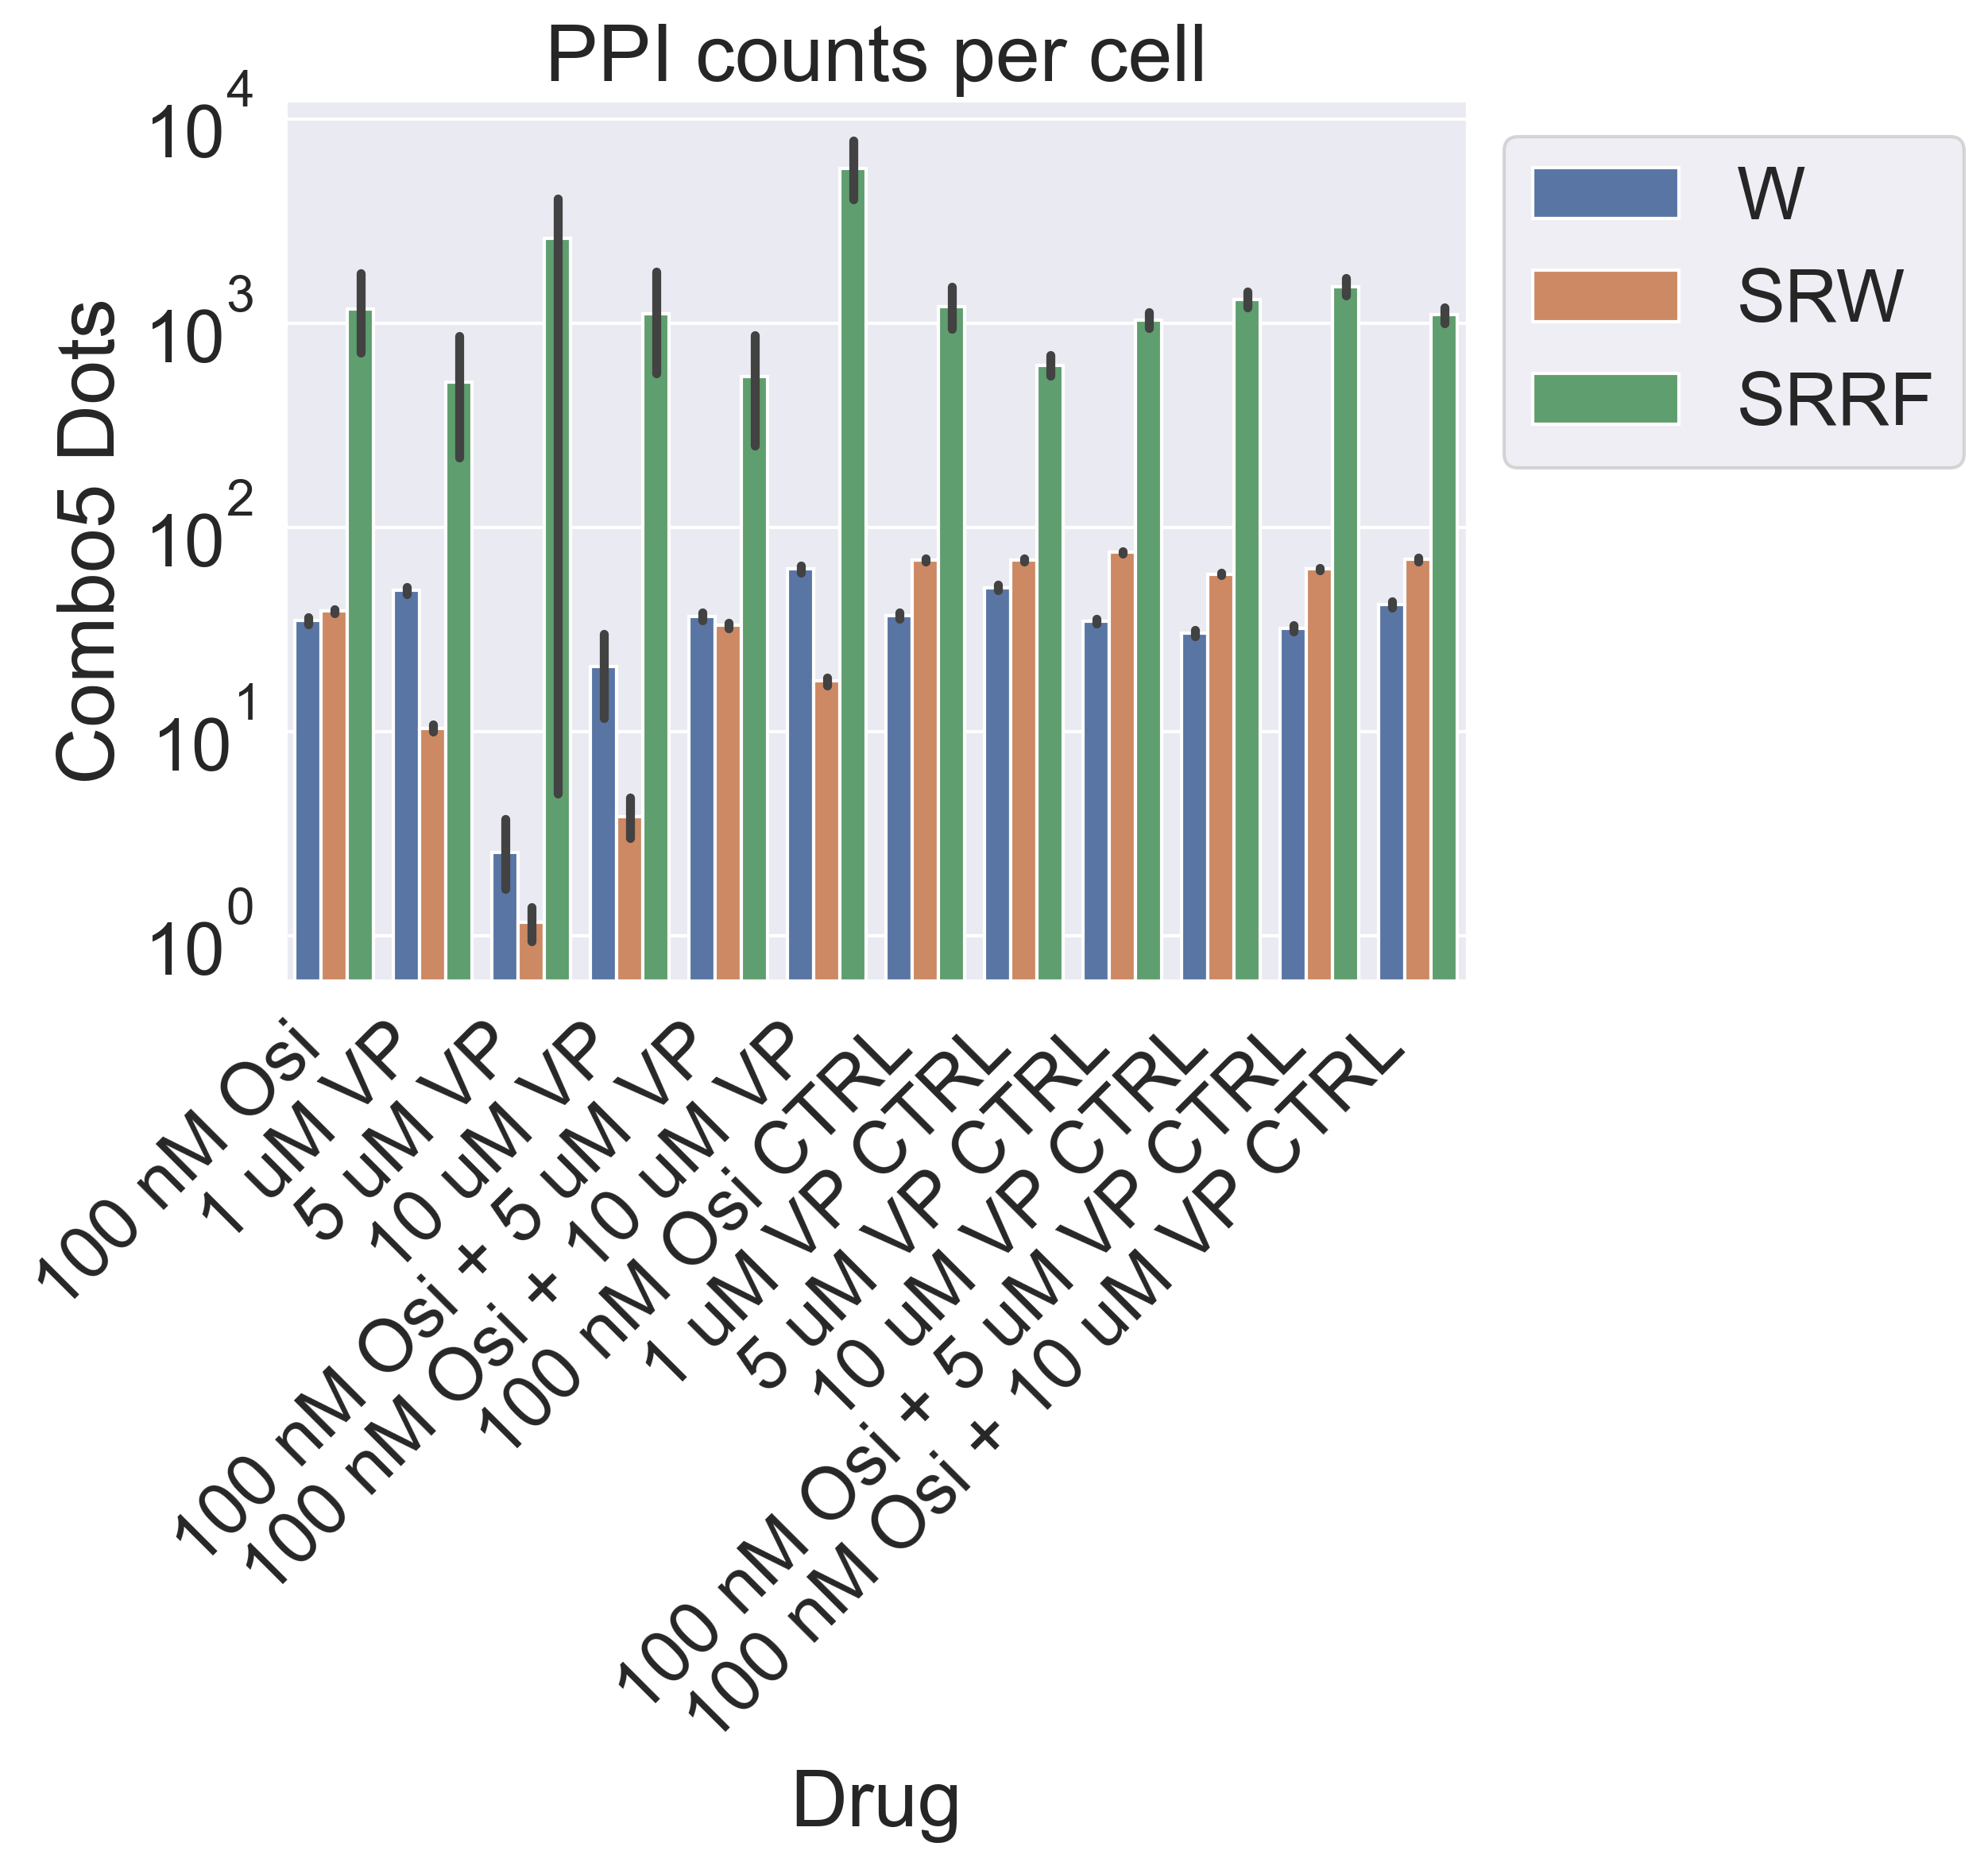

In [7]:
x = 'Drug'
y = 'Combo5 Dots'
hue = 'Microscope'

fig, ax = plt.subplots(dpi = 300)
ax.set_title('PPI counts per cell')
sns.barplot(x = x, y = y, hue = hue, data = dfCell, ax = ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')
ax.set_yscale('log')
ax.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

saveFigLabelTime(fig)

# Quantify cell confluency as survival. Mask area / image area

In [8]:
def reformatSingleCell(path, modality, dfInfo, dimY, dimX):

    df = pd.read_pickle(path)

    # compute total mask area / image dimensions
    imageArea = dimY * dimX
    confluency = df['MaskCytoLabel'].size / imageArea # fraction

    dfOut = pd.DataFrame()
    dfOut['Confluency'] = [confluency]

    # assign microscope
    dfOut['Microscope'] = [modality]
    # assign well label
    wellLabel = path.stem
    row = dfInfo.loc[dfInfo['WellLabel'] == wellLabel]
    assert len(row) == 1
    dfOut['WellLabel'] = [row['WellLabel'].iloc[0]]
    dfOut['Drug'] = [row['Drug'].iloc[0]]

    return dfOut

dfAll = []
for row1 in dfPaths.itertuples(): # each microscope type

    # get Pkl files
    pklFiles = [f for f in Path(row1.PklPath).glob('*.pkl')]
    # compute single cell in parallel
    results = Parallel(n_jobs=-1, prefer = 'threads', verbose = 10)(delayed(reformatSingleCell)\
                                 (fileName, modality = row1.Microscope, dfInfo = dfInfo, dimY = row1.DimY, dimX = row1.DimX) 
                                 for fileName in pklFiles)
    
    dfAll.extend(results)
    
dfFov = pd.concat(dfAll)
# replace microscope labels for consistency
dfFov['Microscope'].replace({'Widefield': 'W', 
                              'Localized': 'SRW', 
                              'Confocal': 'SRRF'}, inplace = True)
dfFov

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  36 | elapsed:   15.7s remaining:  1.6min
[Parallel(n_jobs=-1)]: Done   9 out of  36 | elapsed:   39.8s remaining:  2.0min
[Parallel(n_jobs=-1)]: Done  13 out of  36 | elapsed:  1.3min remaining:  2.3min
[Parallel(n_jobs=-1)]: Done  17 out of  36 | elapsed:  1.9min remaining:  2.2min
[Parallel(n_jobs=-1)]: Done  21 out of  36 | elapsed:  2.3min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done  25 out of  36 | elapsed:  2.6min remaining:  1.1min
[Parallel(n_jobs=-1)]: Done  29 out of  36 | elapsed:  2.8min remaining:   40.9s
[Parallel(n_jobs=-1)]: Done  33 out of  36 | elapsed:  3.2min remaining:   17.1s
[Parallel(n_jobs=-1)]: Done  36 out of  36 | elapsed:  3.3min finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 24 concurrent workers.
[Parallel(n_jobs=-1)]: Done   5 out of  36 | elapsed:   22.1s remaining:  2.3min
[Parallel(n_jobs=-1)]: Done   9 out 

,Confluency,Microscope,WellLabel,Drug
0,0.557142,W,B4,100 nM Osi
0,0.146522,W,B5,1 uM VP
0,0.001001,W,B6,5 uM VP
0,0.003297,W,B7,10 uM VP
0,0.370082,W,B8,100 nM Osi + 5 uM VP
...,...,...,...,...
0,0.001262,SRRF,E5,1 uM VP CTRL
0,0.003301,SRRF,E6,5 uM VP CTRL
0,0.019693,SRRF,E7,10 uM VP CTRL
0,4.973827,SRRF,E8,100 nM Osi + 5 uM VP CTRL


# Plot cell confluency (survival) compared across drug groups

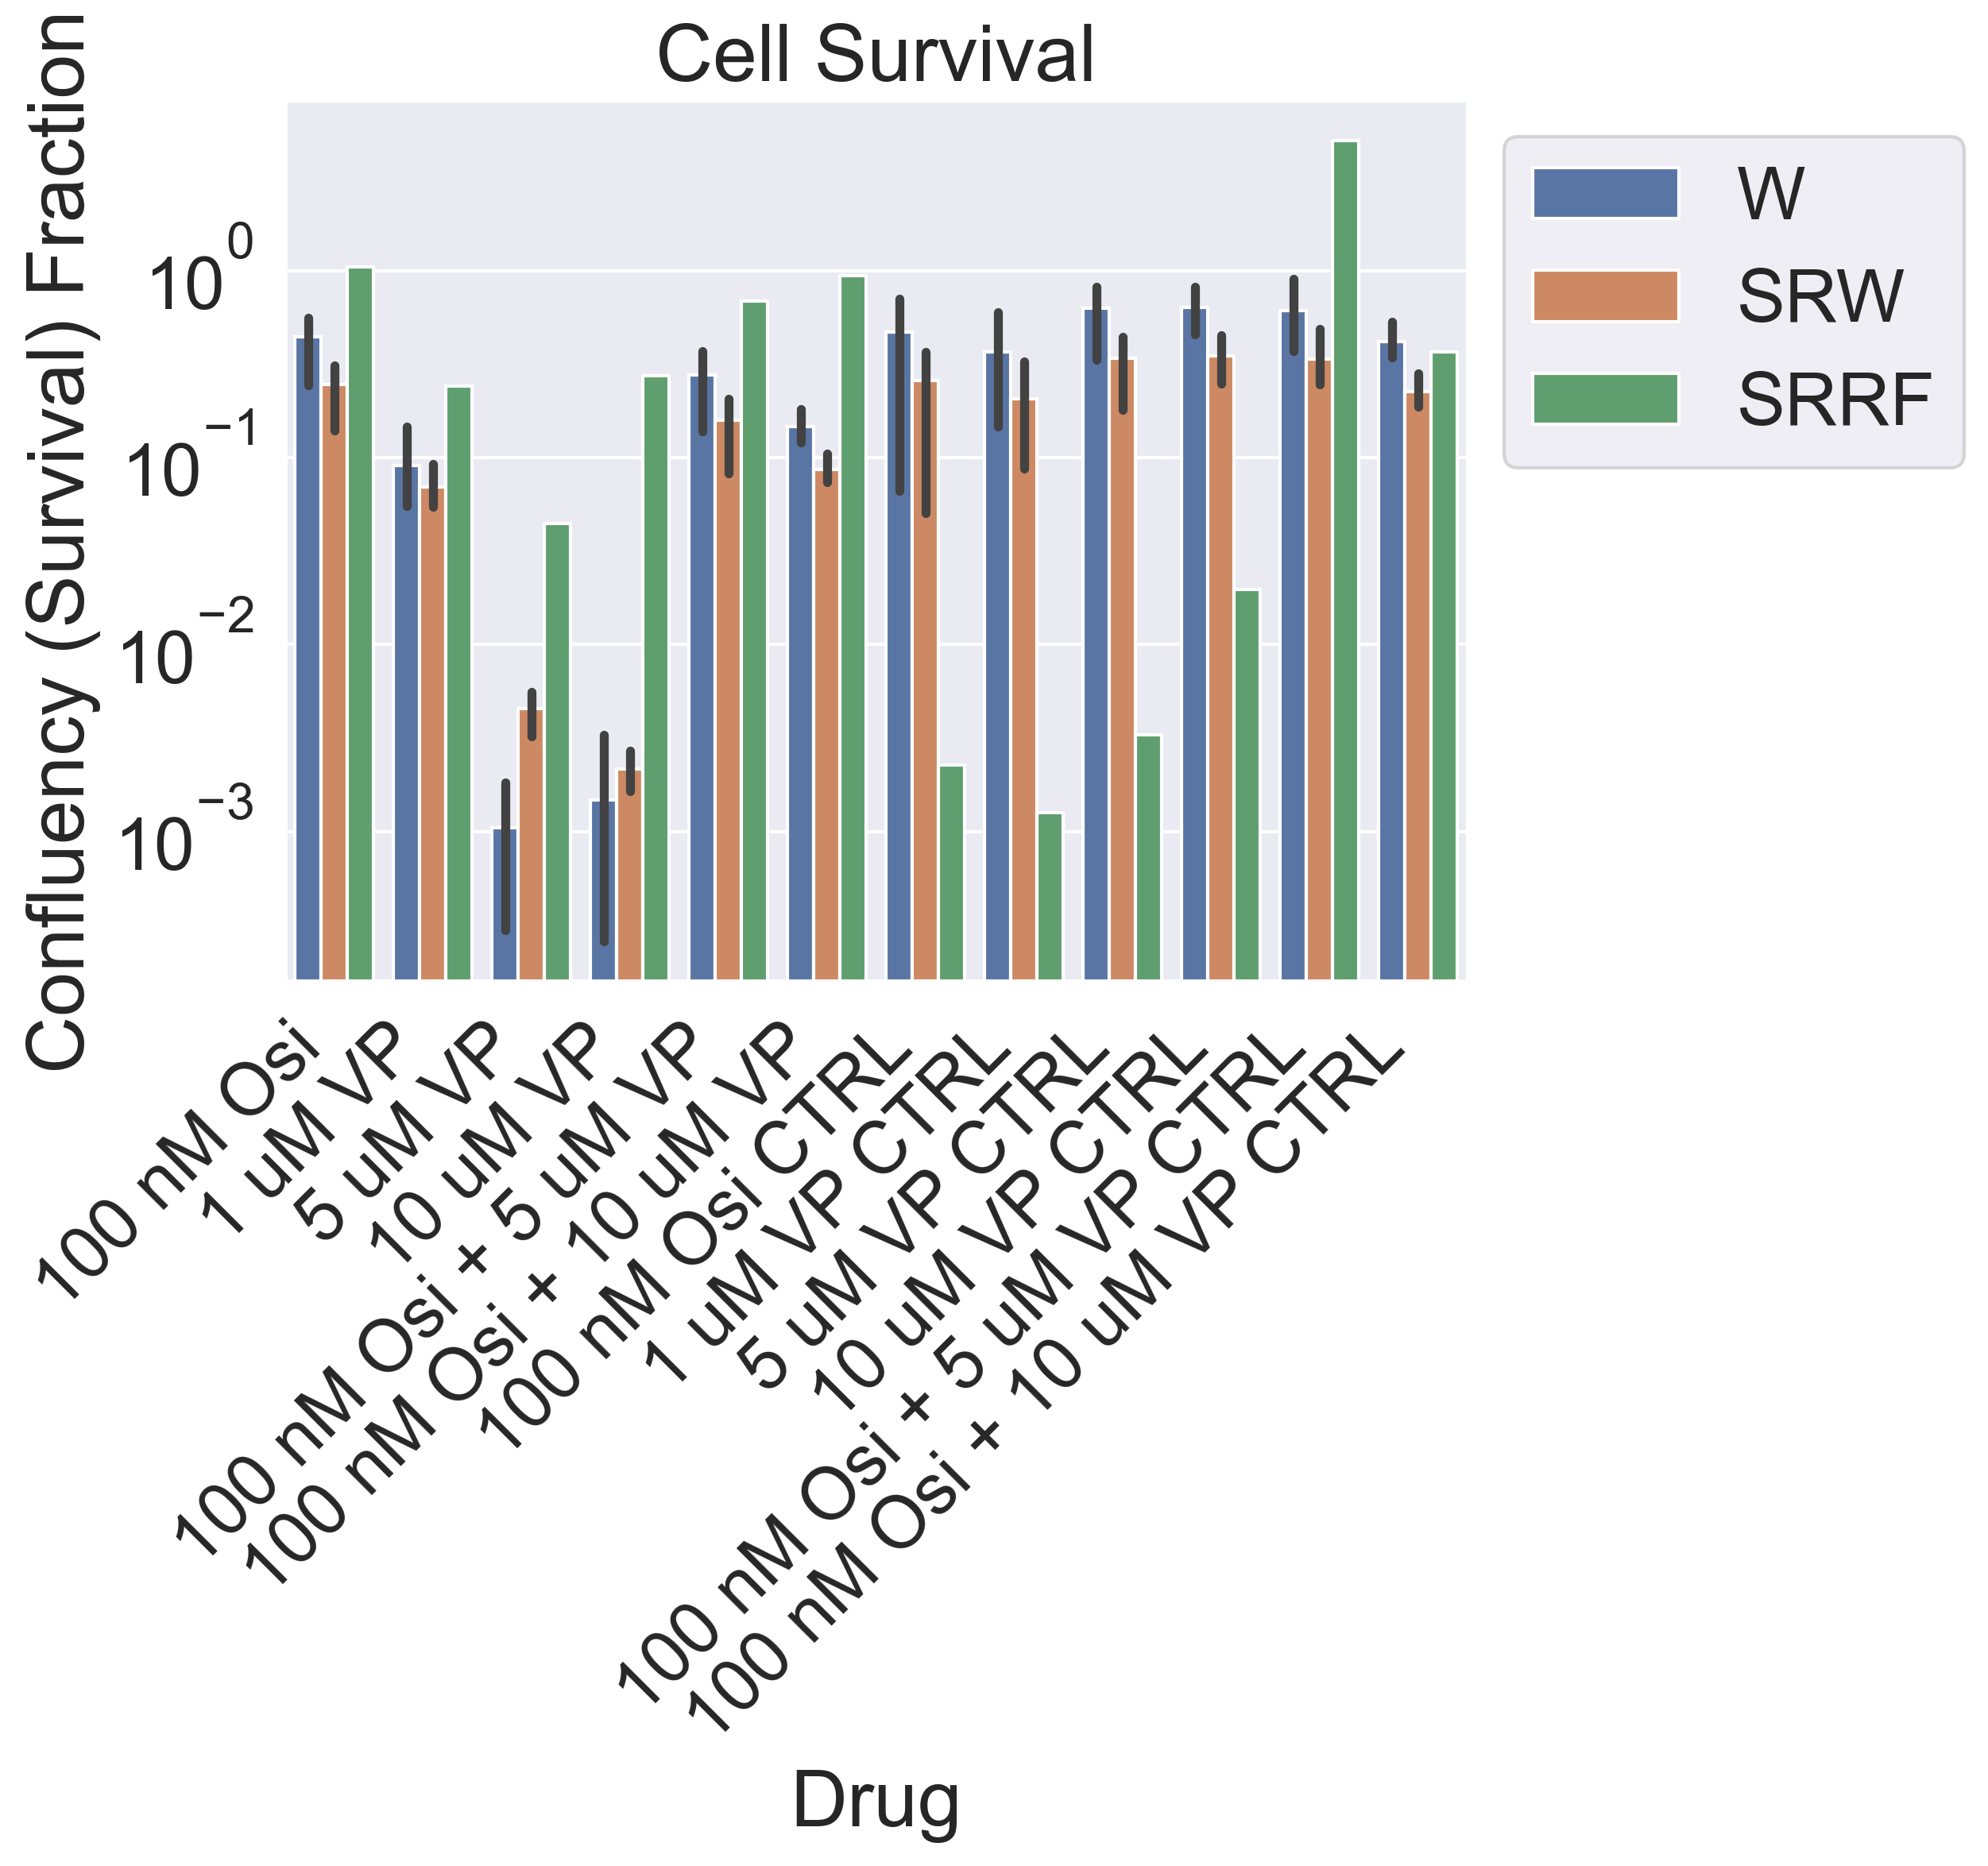

In [9]:
x = 'Drug'
y = 'Confluency'
hue = 'Microscope'

fig, ax = plt.subplots(dpi = 300)
ax.set_title('Cell Survival')
ax.set_yscale('log')

sns.barplot(x = x, y = y, hue = hue, data = dfFov, ax = ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation = 45, ha = 'right')
ax.legend(loc = 'upper left', bbox_to_anchor = (1, 1))

ax.set_ylabel('Confluency (Survival) Fraction')

saveFigLabelTime(fig)